# 📊 Knowledge Tracing: pyBKT & Evaluasi Akurasi (OULAD Dataset)
---
Notebook ini fokus pada pemodelan probabilitas penguasaan konsep menggunakan **Bayesian Knowledge Tracing (pyBKT)**.

Di sini kita juga akan mengukur **Akurasi Model**, **AUC (Area Under ROC Curve)**, dan melakukan **Cross Validation** agar kita tahu seberapa baik performa model yang dibuat.

In [1]:
# 1. Install & Import Libraries
!pip install pyBKT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pyBKT.models import Model

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Menghubungkan ke Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/AI-Learning Path/'
except:
    print("Tidak berjalan di Google Colab. Pastikan data ada di direktori lokal.")
    BASE_PATH = './'

print("\n✅ Setup & Import Selesai!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyBKT: filename=pyBKT-1.4.2-cp312-cp312-linux_x86_64.whl size=1130552 sha256=305dc0f5080d560ccf07297ca580eb34c558c4981745800f9d5c3a8a8debc056
  Stored in directory: /root/.cache/pip/wheels/86/91/2f/0eb4389642bed5183ec3d8d025ef7ff02099f08dafb9e0cc19
Successfully built pyBKT
Mounted at /content/drive

✅ Setup & Import Selesai!


### 2. Memuat & Menyiapkan Data
Kita format data interaksi (*studentAssessment*) agar sesuai dengan standar pyBKT: `user_id`, `skill_name`, `correct`, `order_id`.

In [7]:
%%time
assessments = pd.read_csv(os.path.join(BASE_PATH, 'assessments.csv'))
studentAssessment = pd.read_csv(os.path.join(BASE_PATH, 'studentAssessment.csv'))

# Gabungkan data
df = studentAssessment.merge(assessments, on='id_assessment')

# Buat fitur 'correct' (Lulus = skor >= 40 sesuai standar Open University)
df['correct'] = (df['score'] >= 40).astype(int)

# Urutkan berdasarkan waktu pengumpulan tugas
df = df.sort_values(['id_student', 'date_submitted'])

# Bikin order_id per siswa (urutan interaksi)
df['order_id'] = df.groupby('id_student').cumcount() + 1

# Format akhir untuk pyBKT
bkt_data = df.rename(columns={
    'id_student': 'user_id',
    'assessment_type': 'skill_name'
})[['user_id', 'skill_name', 'correct', 'order_id']]

print(f"Data siap dilatih! Total {len(bkt_data)} interaksi dari {bkt_data['user_id'].nunique()} mahasiswa.")
bkt_data.head()

Data siap dilatih! Total 173912 interaksi dari 23369 mahasiswa.
CPU times: user 161 ms, sys: 37 ms, total: 198 ms
Wall time: 210 ms


,user_id,skill_name,correct,order_id
1756,6516,TMA,1,1
1970,6516,TMA,1,2
2376,6516,TMA,1,3
2685,6516,TMA,1,4
2871,6516,TMA,1,5


### 3. Melatih Model BKT (Bayesian Knowledge Tracing)

In [8]:
# Inisialisasi Model pyBKT
model = Model(seed=42, num_fits=1)

# Melatih Model
print("Sedang melatih model BKT...")
model.fit(data=bkt_data)
print("Pelatihan Selesai!\n")

# Menampilkan Parameter Hasil Pelatihan (per jenis Assessment/Skill)
params = model.params()
print("=== Parameter Kognitif Model BKT ===")
print("P(init)  : Probabilitas awal menguasai konsep sebelum asesmen")
print("P(learn) : Probabilitas beralih dari tidak paham menjadi paham")
print("P(guess) : Probabilitas menebak benar padahal belum paham")
print("P(slip)  : Probabilitas salah menjawab padahal sudah paham\n")
display(params)

Sedang melatih model BKT...
Pelatihan Selesai!

=== Parameter Kognitif Model BKT ===
P(init)  : Probabilitas awal menguasai konsep sebelum asesmen
P(learn) : Probabilitas beralih dari tidak paham menjadi paham
P(guess) : Probabilitas menebak benar padahal belum paham
P(slip)  : Probabilitas salah menjawab padahal sudah paham



value
skill param   class          
TMA   prior   default 0.90474
      learns  default 0.00014
      guesses default 0.65884
      slips   default 0.02671
      forgets default 0.00000
CMA   prior   default 0.38326
      learns  default 0.85959
      guesses default 0.94974
      slips   default 0.02025
      forgets default 0.00000
Exam  prior   default 0.51756
      learns  default 0.49161
      guesses default 0.76247
      slips   default 0.00707
      forgets default 0.00000

### 4. Evaluasi Akurasi & Cross Validation 🔍
Di sini kita menggunakan **K-Fold Cross Validation** (membagi data uji dan latih beberapa kali) untuk menghindari *overfitting* dan memastikan akurasi model reliabel.

Metrik yang digunakan:
- **Accuracy**: Rasio ketepatan prediksi lulus/gagal.
- **AUC (Area Under Curve)**: Kemampuan model membedakan antara siswa yang benar-benar menguasai materi dan yang tidak (semakin mendekati 1.0 semakin baik).
- **RMSE**: Tingkat error probabilitas (semakin rendah semakin baik).

In [9]:
# 4.1 Cross Validation (5-Fold)
print("Menjalankan 5-Fold Cross Validation... Ini mungkin butuh waktu beberapa menit.")

# pyBKT menyediakan metode crossvalidate built-in
# Kita kumpulkan metrik AUC, Accuracy, dan RMSE
cv_results = model.crossvalidate(data=bkt_data, folds=5, metric=['auc', 'accuracy', 'rmse'])

print("\n✅ Hasil Cross Validation per Skill/Tipe Assessment:")
display(cv_results)

Menjalankan 5-Fold Cross Validation... Ini mungkin butuh waktu beberapa menit.

✅ Hasil Cross Validation per Skill/Tipe Assessment:


,auc,accuracy,rmse
skill,,,
TMA,0.61001,0.94461,0.22380
CMA,0.68479,0.97543,0.15011
Exam,0.51716,0.88577,0.31763


/tmp/ipykernel_6978/2056347642.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='skill', y='accuracy', ax=axes[0], palette='viridis')
/tmp/ipykernel_6978/2056347642.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='skill', y='auc', ax=axes[1], palette='magma')


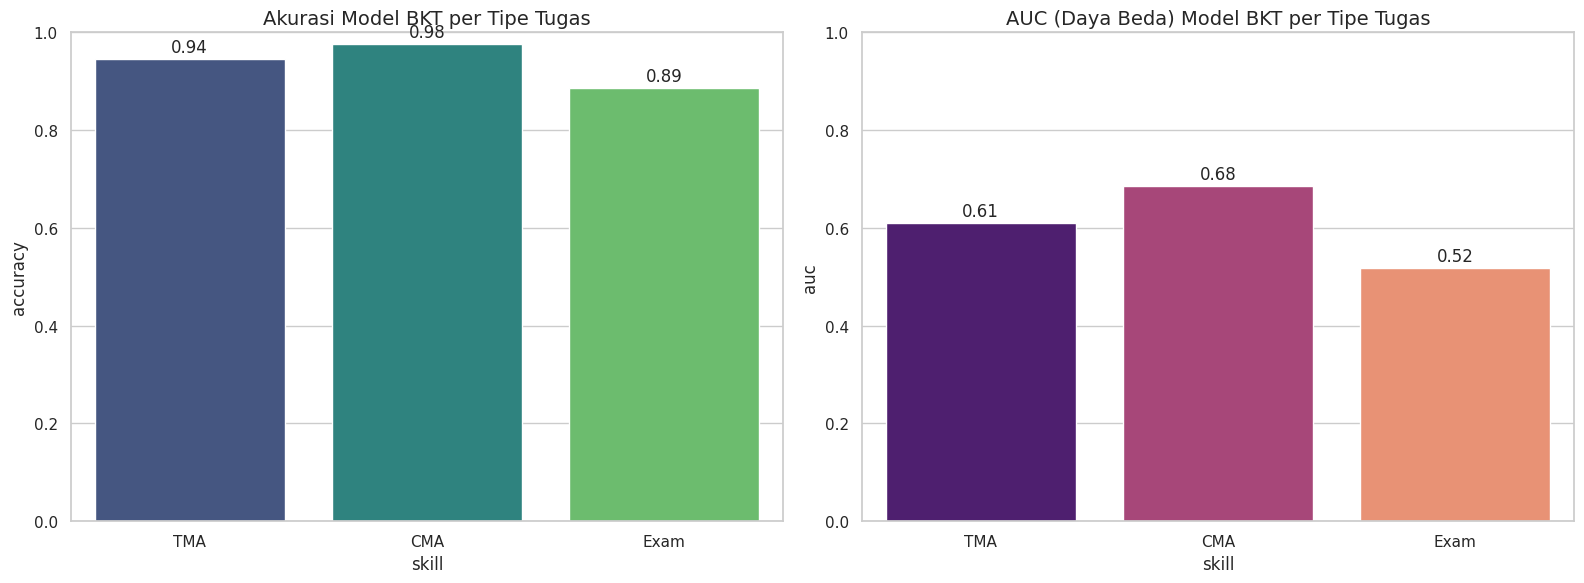

In [10]:
# 4.2 Visualisasi Performa Model (AUC & Accuracy)

metrics_df = cv_results.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
sns.barplot(data=metrics_df, x='skill', y='accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Akurasi Model BKT per Tipe Tugas', fontsize=14)
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points')

# Plot AUC
sns.barplot(data=metrics_df, x='skill', y='auc', ax=axes[1], palette='magma')
axes[1].set_title('AUC (Daya Beda) Model BKT per Tipe Tugas', fontsize=14)
axes[1].set_ylim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

### 5. Prediksi Probabilitas Mastery (*Real-time*)
Melihat probabilitas ketuntasan belajar `P(mastery)` untuk masing-masing siswa berdasarkan riwayat nilainya.

In [12]:
# Melakukan prediksi state mastery
model.fit(data=bkt_data) # <-- Tambahkan baris ini di atas model.predict
predictions = model.predict(data=bkt_data)

print("Sampel hasil Prediksi (Kolom 'correct_predictions' adalah probabilitas P(mastery)):")
display(predictions[['user_id', 'skill_name', 'correct', 'correct_predictions']].head(10))

Sampel hasil Prediksi (Kolom 'correct_predictions' adalah probabilitas P(mastery)):


,user_id,skill_name,correct,correct_predictions
1756,6516,TMA,1,0.95622
1970,6516,TMA,1,0.95649
2376,6516,TMA,1,0.95671
2685,6516,TMA,1,0.95688
2871,6516,TMA,1,0.95703
88494,8462,TMA,1,0.95622
90368,8462,TMA,1,0.95649
90712,8462,TMA,1,0.95671
92364,8462,TMA,1,0.95688
76301,8462,TMA,1,0.95703
